# 常见策略Alpha/Strategy/Schemes

## Momentum

<img src="https://raw.githubusercontent.com/tomctang/NB_img/main/momentum.png" alt="C" width="700">


In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Function to calculate momentum return during h look_back periode
def calculate_momentum(prices, lookback_period):
    momentum = prices.pct_change(lookback_period)
    return momentum

# Constants
LOOKBACK_PERIOD = 63  # Approximately 3 months of trading days for 2 years of période
REBALANCE_FREQ = '1D'  # Daily rebalancing

# Use calculate_momentum -> long/short signals -> plotting
def momentum_strategy(ticker, start_date, end_date):
    # Download data and select the 'Close' column, which is already a DataFrame
    data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
    data = data.rename(columns={'Close': ticker})

    # momentum calculation
    momentum_scores = calculate_momentum(data, LOOKBACK_PERIOD)

    # Initialisation of long and short signals
    long_signals = pd.DataFrame(False, index=data.index, columns=[ticker])
    short_signals = pd.DataFrame(False, index=data.index, columns=[ticker])

    # Matching momentum scores index and long ans short signals index
    aligned_momentum_scores = momentum_scores.reindex(data.index)

    for date in aligned_momentum_scores.index:
        today_momentum = aligned_momentum_scores.loc[date, ticker]
        if isinstance(today_momentum, pd.Series):
            today_momentum = today_momentum.iloc[0]  # take the first value if multiple
        long_signals.at[date, ticker] = today_momentum > 0
        short_signals.at[date, ticker] = today_momentum <= 0

    # Filter signals daily frequency and fill daily signals : 
    # ex : if we have a long signal, we fill all daily signals by long until the next short signal 
    long_signals = long_signals.resample(REBALANCE_FREQ).ffill().astype(bool)
    short_signals = short_signals.resample(REBALANCE_FREQ).ffill().astype(bool)

    # Plotting the signals
    plt.figure(figsize=(15, 7))
    plt.plot(data, label=f'{ticker} Price')
    plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
    plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')
    plt.title(f'{ticker} Momentum Signals')
    plt.legend()
    plt.show()

    return long_signals, short_signals, data

# get long-to-short signal ratio for selected period
def rank_asset(ticker, long_signals, short_signals, start_date, end_date):
    # Count the number of long and short signals within the period
    nb_long_signals = long_signals.loc[start_date:end_date, ticker].sum()
    nb_short_signals = short_signals.loc[start_date:end_date, ticker].sum()
    # Avoid division by zero
    if nb_short_signals == 0:
        ratio = float('inf')  # Assign infinity if no short signals
    else:
        ratio = nb_long_signals / nb_short_signals

    return ratio

# 如果算法检测到 3 个连续的多(空)头信号，我们就进入买入(清算)仓位
def execution_momentum_strategy(ticker, start_date, end_date):
    long_signals, short_signals, data = momentum_strategy(ticker, start_date, end_date)
    in_position = False
    entry_price = 0
    total_return = 0
    entry_date = []
    exit_date = []
    entry_price_list = []
    strategy_retrace_price=[]

    # Adjust end_date to the closest available date in data if it's not present
    end_date = pd.to_datetime(end_date)
    if end_date not in data.index:
        end_date = data.index[data.index < end_date][-1]

    # Create rolling series for signals
    rolling_long_signals = long_signals[ticker].rolling(window=3).sum()
    rolling_short_signals = short_signals[ticker].rolling(window=3).sum()

    for date in data.index:
        if not in_position and rolling_long_signals.loc[date] == 3:
            entry_price = float(data.loc[date, ticker])
            entry_price_list.append(entry_price)
            strategy_retrace_price.append(entry_price)
            entry_date.append(date)
            in_position = True
        elif in_position and (rolling_short_signals.loc[date] == 3 or date == end_date):
            exit_price = float(data.loc[date, ticker])
            total_return += (exit_price - entry_price)
            exit_date.append(date)
            strategy_retrace_price.append(exit_price)
            in_position = False

    total_return_percent = ((total_return / entry_price_list[0]) * 100) if entry_price_list else 0
    strategy_retrace_price = pd.Series(strategy_retrace_price)

    return total_return_percent, entry_date, exit_date, strategy_retrace_price

# execution_momentum_strategy 计算最终回报
def momentun_strategy_traing_final(tickers, start_date, end_date):
    for ticker in tickers:
        total_return,entry_date,exit_date, strategy_retrace_price= execution_momentum_strategy(ticker, start_date, end_date)
        print(f"Total Return Rate: {total_return:.2f} %")
        print(f"Entry Dates are: {entry_date}")
        print(f"Exit Dates are: {exit_date}")

    return execution_momentum_strategy(ticker, start_date, end_date)


/tmp/ipykernel_56160/3720828892.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_56160/3720828892.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
/tmp/ipykernel_56160/3720828892.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')


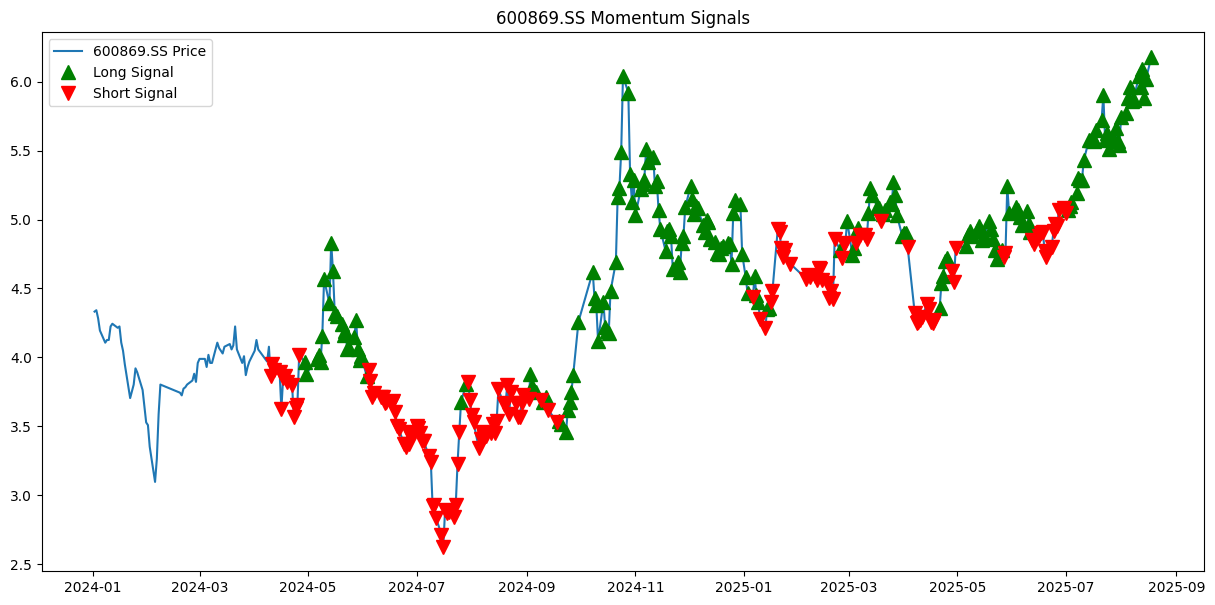

/tmp/ipykernel_56160/3720828892.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
[*********************100%***********************]  1 of 1 completed

The long-to-short signal ratio for yours from 2024-01-01 to 2025-08-19 is: 1.31



/tmp/ipykernel_56160/3720828892.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
/tmp/ipykernel_56160/3720828892.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')


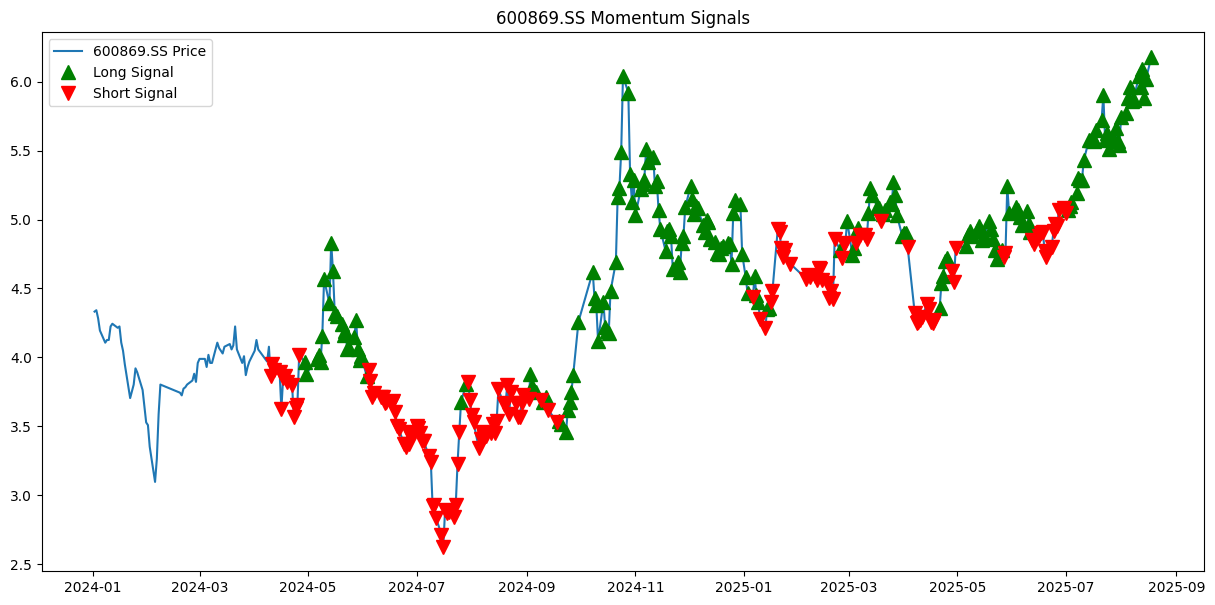

/tmp/ipykernel_56160/3720828892.py:88: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  entry_price = float(data.loc[date, ticker])
/tmp/ipykernel_56160/3720828892.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exit_price = float(data.loc[date, ticker])
/tmp/ipykernel_56160/3720828892.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
[*********************100%***********************]  1 of 1 completed


Total Return Rate: 12.92 %
Entry Dates are: [Timestamp('2024-05-06 00:00:00'), Timestamp('2024-07-29 00:00:00'), Timestamp('2024-09-05 00:00:00'), Timestamp('2024-09-23 00:00:00'), Timestamp('2025-03-03 00:00:00'), Timestamp('2025-03-14 00:00:00'), Timestamp('2025-04-23 00:00:00'), Timestamp('2025-05-08 00:00:00'), Timestamp('2025-07-04 00:00:00')]
Exit Dates are: [Timestamp('2024-06-06 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-18 00:00:00'), Timestamp('2025-01-13 00:00:00'), Timestamp('2025-03-10 00:00:00'), Timestamp('2025-04-07 00:00:00'), Timestamp('2025-04-30 00:00:00'), Timestamp('2025-06-16 00:00:00'), Timestamp('2025-08-18 00:00:00')]


/tmp/ipykernel_56160/3720828892.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
/tmp/ipykernel_56160/3720828892.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')


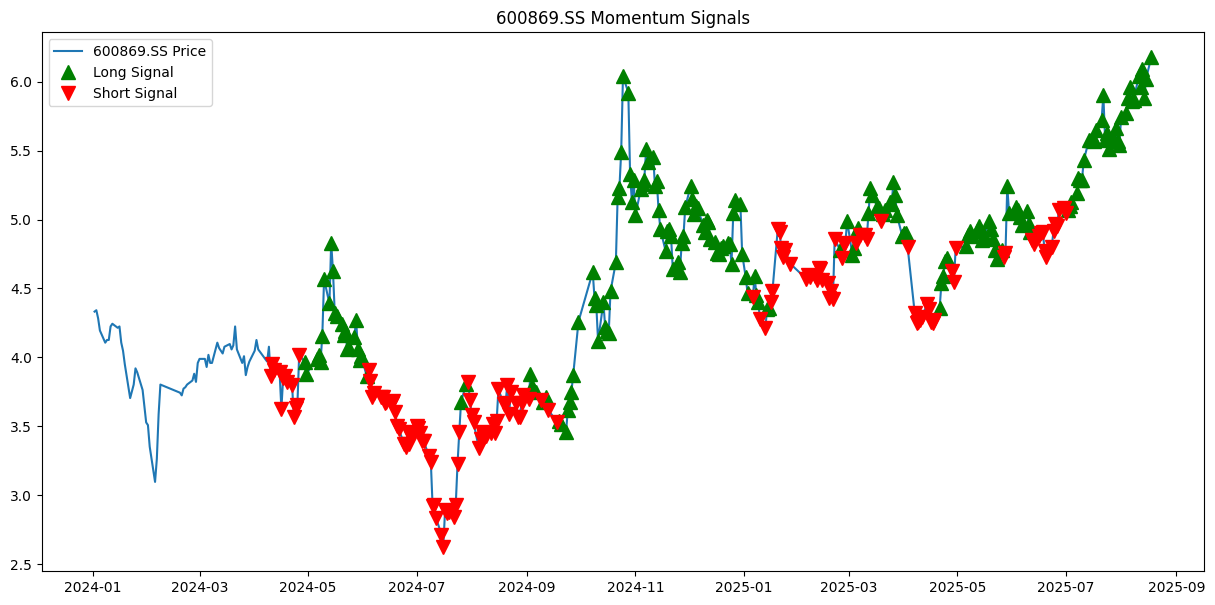

/tmp/ipykernel_56160/3720828892.py:88: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  entry_price = float(data.loc[date, ticker])
/tmp/ipykernel_56160/3720828892.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exit_price = float(data.loc[date, ticker])


(12.923397335082923,
 [Timestamp('2024-05-06 00:00:00'),
  Timestamp('2024-07-29 00:00:00'),
  Timestamp('2024-09-05 00:00:00'),
  Timestamp('2024-09-23 00:00:00'),
  Timestamp('2025-03-03 00:00:00'),
  Timestamp('2025-03-14 00:00:00'),
  Timestamp('2025-04-23 00:00:00'),
  Timestamp('2025-05-08 00:00:00'),
  Timestamp('2025-07-04 00:00:00')],
 [Timestamp('2024-06-06 00:00:00'),
  Timestamp('2024-08-01 00:00:00'),
  Timestamp('2024-09-18 00:00:00'),
  Timestamp('2025-01-13 00:00:00'),
  Timestamp('2025-03-10 00:00:00'),
  Timestamp('2025-04-07 00:00:00'),
  Timestamp('2025-04-30 00:00:00'),
  Timestamp('2025-06-16 00:00:00'),
  Timestamp('2025-08-18 00:00:00')],
 0     3.989292
 1     3.714844
 2     3.810000
 3     3.580000
 4     3.760000
 5     3.530000
 6     3.460000
 7     4.210000
 8     4.740000
 9     4.890000
 10    5.180000
 11    4.320000
 12    4.590000
 13    4.790000
 14    4.920000
 15    4.880000
 16    5.130000
 17    6.180000
 dtype: float64)

In [2]:
START_DATE = '2024-01-01'
END_DATE = '2025-08-19'
COMPANY = '600869.SS' # 'MC.PA' # 

# test 1: momentum
# Set up the analysis period of a company, call momentum strategy & rank_asset
long_signals_aapl, short_signals_aapl, data_aapl = momentum_strategy(COMPANY, START_DATE, END_DATE)
ratio = rank_asset(COMPANY, long_signals_aapl, short_signals_aapl, START_DATE, END_DATE)
print(f"The long-to-short signal ratio for yours from {START_DATE} to {END_DATE} is: {ratio:.2f}")

# test 2: execution & final return
group_tickers = [COMPANY]
momentun_strategy_traing_final(group_tickers, START_DATE, END_DATE)

## 配对交易Pair trading


/tmp/ipykernel_6210/879198764.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  10 of 10 completed
/tmp/ipykernel_6210/879198764.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()


Covariance Matrix:
Ticker       1913.HK    BRBY.L    CDI.PA    CFR.SW        EL    KER.PA  \
Ticker                                                                   
1913.HK  4037.290063  0.087756  0.260410  0.215995  0.048218  0.083262   
BRBY.L      0.087756  0.109398  0.054839  0.057249  0.030438  0.054555   
CDI.PA      0.260410  0.054839  0.071739  0.056259  0.029419  0.055250   
CFR.SW      0.215995  0.057249  0.056259  0.090602  0.030796  0.055955   
EL          0.048218  0.030438  0.029419  0.030796  0.077852  0.028980   
KER.PA      0.083262  0.054555  0.055250  0.055955  0.028980  0.082738   
MC.PA       0.245646  0.055796  0.063863  0.058633  0.030803  0.058120   
RL         -0.313904  0.036387  0.033986  0.039765  0.044081  0.034149   
RMS.PA      0.006548  0.038933  0.040931  0.039832  0.019559  0.039882   
UHR.SW      0.319713  0.051295  0.049814  0.069288  0.027933  0.050541   

Ticker      MC.PA        RL    RMS.PA    UHR.SW  
Ticker                                    

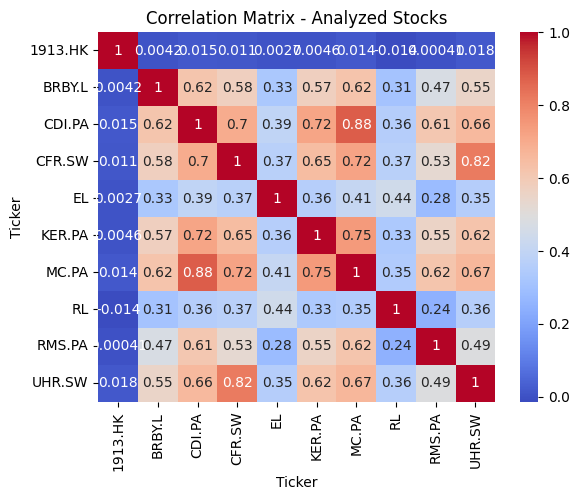

/tmp/ipykernel_6210/879198764.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()


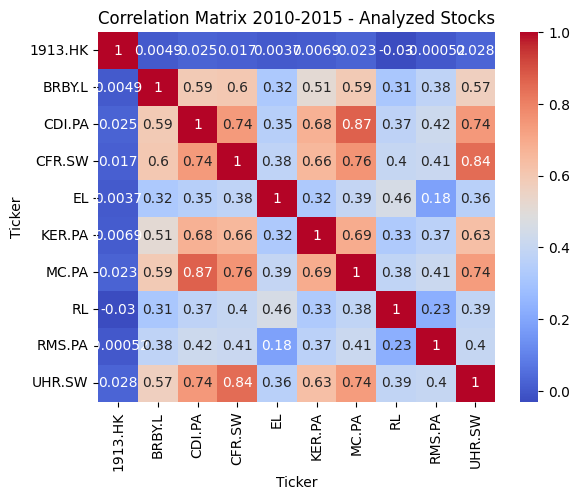

/tmp/ipykernel_6210/879198764.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()


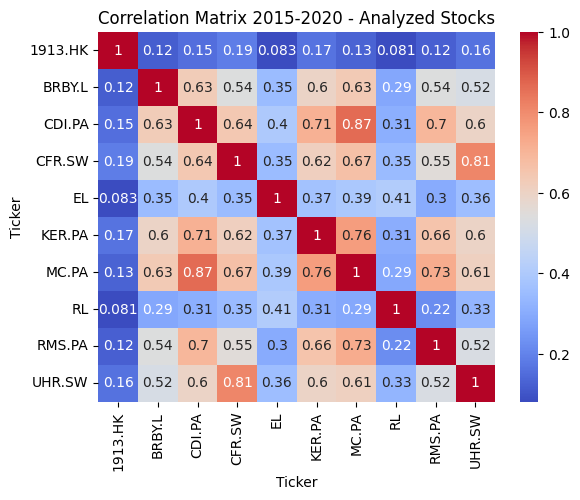

/tmp/ipykernel_6210/879198764.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change()


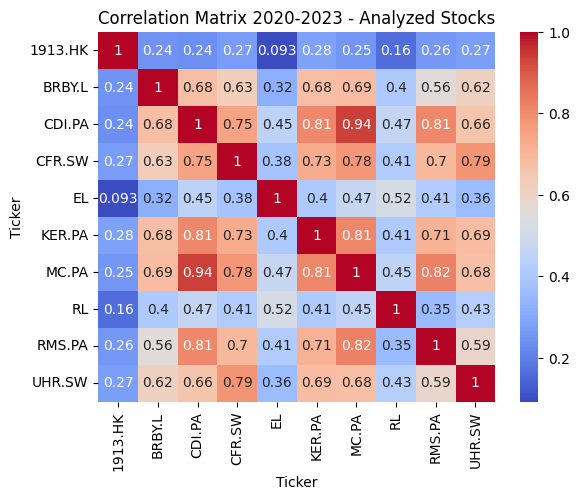

/tmp/ipykernel_6210/879198764.py:67: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(assets, start=start_date, end=end_date)['Close']
[*********************100%***********************]  10 of 10 completed
/tmp/ipykernel_6210/879198764.py:70: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = stock_data.pct_change().dropna()


The best correlated pair for trading is: ('MC.PA', 'CDI.PA')


In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def Correlation_analysis(tickers, start_date='2010-01-01', end_date='2023-01-01'):
    # Fetch the stock data
    stock_data = yf.download(tickers, start=start_date, end=end_date)['Close']

    # Function to compute returns
    def compute_return(prices):
        return prices.pct_change()

    # Compute returns for the stocks
    stock_returns = stock_data.apply(compute_return)

    # Drop NA values
    stock_returns = stock_returns.dropna()

    # Function to compute the covariance matrix
    def compute_covariance_matrix(returns, multiplicator=252):
        return returns.cov() * multiplicator

    # Function to compute the correlation matrix
    def compute_correlation_matrix(returns):
        return returns.corr()

    # Compute and print Covariance Matrix
    cov_matrix = compute_covariance_matrix(stock_returns)
    print("Covariance Matrix:")
    print(cov_matrix)

    # Compute and print Correlation Matrix
    corr_matrix = compute_correlation_matrix(stock_returns)
    print("\nCorrelation Matrix:")
    print(corr_matrix)

    # Visualization using Seaborn for the entire period
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix - Analyzed Stocks')
    plt.show()

    # Visualization for different time periods
    periods = {
        "2010-2015": ("2010-01-01", "2014-12-31"),
        "2015-2020": ("2015-01-01", "2020-12-31"),
        "2020-2023": ("2021-01-01", "2023-12-31")
    }

    for period, (start_date, end_date) in periods.items():
        temp_returns = stock_data[start_date:end_date].apply(compute_return)
        temp_corr_matrix = compute_correlation_matrix(temp_returns.dropna())
        sns.heatmap(temp_corr_matrix, annot=True, cmap='coolwarm')
        plt.title(f'Correlation Matrix {period} - Analyzed Stocks')
        plt.show()

# Example usage
luxury_tickers = [
    'MC.PA', 'KER.PA', 'CFR.SW', 'RMS.PA', 'BRBY.L', '1913.HK', 'EL', 'UHR.SW', 'RL', 'CDI.PA'
]

Correlation_analysis(luxury_tickers)

def find_best_correlated_pair(assets, start_date='2010-01-01', end_date='2023-01-01'):
    # Downloading data
    stock_data = yf.download(assets, start=start_date, end=end_date)['Close']

    # Calculating returns
    returns = stock_data.pct_change().dropna()

    # Calculating correlation matrix
    correlation_matrix = returns.corr()

    # Finding the pair with the highest correlation
    correlation_matrix = correlation_matrix.unstack()
    sorted_pairs = correlation_matrix.sort_values(kind="quicksort", ascending=False)

    # Filter out self correlations
    sorted_pairs = sorted_pairs[sorted_pairs.index.get_level_values(0) != sorted_pairs.index.get_level_values(1)]

    best_pair = sorted_pairs.idxmax()

    return best_pair

# Example usage
luxury_tickers = ['MC.PA', 'KER.PA', 'CFR.SW', 'RMS.PA', 'BRBY.L', '1913.HK', 'EL', 'UHR.SW', 'RL', 'CDI.PA']
best_correlated_pair = find_best_correlated_pair(luxury_tickers)
print(f"The best correlated pair for trading is: {best_correlated_pair}")

/tmp/ipykernel_6210/3476043409.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_symbols, start=start_date, end=end_date)['Close']
[*********************100%***********************]  2 of 2 completed
/tmp/ipykernel_6210/3476043409.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if buy_signal[i] and capital >= stock_data['MC.PA'].iloc[i]:
/tmp/ipykernel_6210/3476043409.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif sell_signal[i] and mc_stocks > 0:


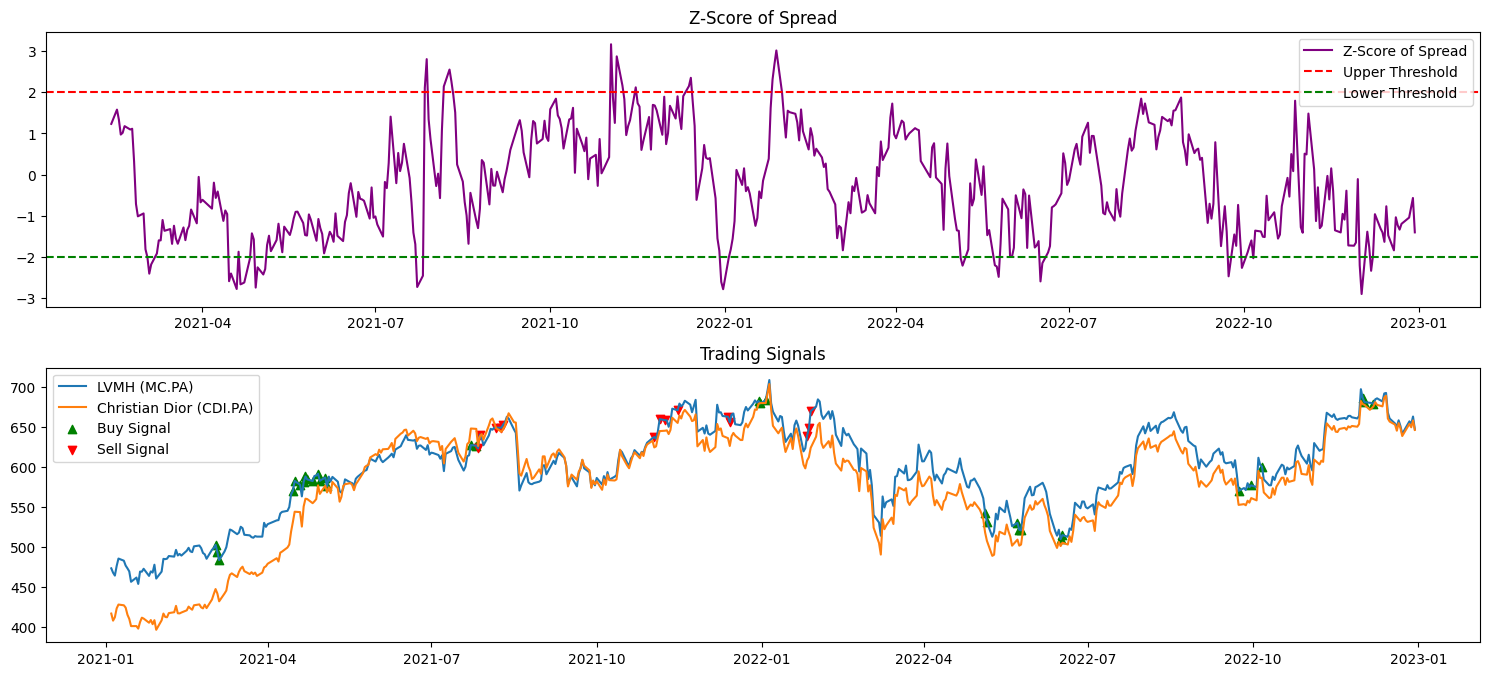

Final return from the strategy:  22932.308166503906


In [15]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download stock data for LVMH and Christian Dior
start_date = '2021-01-01'
end_date = '2023-01-01'
stock_symbols = ['MC.PA', 'CDI.PA']  # MC.PA for LVMH and CDI.PA for Christian Dior
stock_data = yf.download(stock_symbols, start=start_date, end=end_date)['Close']

# Calculate the spread
spread = stock_data['MC.PA'] - stock_data['CDI.PA']

# Calculate the rolling mean and standard deviation of the spread
window = 30
rolling_mean = spread.rolling(window=window).mean()
rolling_std = spread.rolling(window=window).std()

# Calculate the Z-Score
z_score = (spread - rolling_mean) / rolling_std

# Define thresholds for trading signals
upper_threshold = 2
lower_threshold = -2

# Generate trading signals
buy_signal = (z_score < lower_threshold)
sell_signal = (z_score > upper_threshold)

# Calculate returns - assuming we buy one stock of MC.PA and sell one stock of CDI.PA when a buy signal is generated, and vice versa for sell signals
capital = 10000  # Starting capital
mc_stocks = 0
cdi_stocks = 0

for i in range(len(z_score)):
    if buy_signal[i] and capital >= stock_data['MC.PA'].iloc[i]:
        # Buy MC.PA and sell CDI.PA
        mc_stocks += 1
        cdi_stocks -= 1
        capital -= stock_data['MC.PA'].iloc[i]
        capital += stock_data['CDI.PA'].iloc[i]
    elif sell_signal[i] and mc_stocks > 0:
        # Sell MC.PA and buy CDI.PA
        mc_stocks -= 1
        cdi_stocks += 1
        capital += stock_data['MC.PA'].iloc[i]
        capital -= stock_data['CDI.PA'].iloc[i]

# Final capital after selling any remaining stocks
capital += mc_stocks * stock_data['MC.PA'].iloc[-1]
capital += -cdi_stocks * stock_data['CDI.PA'].iloc[-1]
final_return = capital - 10000

# Plotting
plt.figure(figsize=(15, 10))

# Plot Z-Score
plt.subplot(3, 1, 2)
plt.plot(z_score, label='Z-Score of Spread', color='purple')
plt.axhline(upper_threshold, color='red', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='green', linestyle='--', label='Lower Threshold')
plt.title('Z-Score of Spread')
plt.legend()

# Plot Buy/Sell Signals
plt.subplot(3, 1, 3)
plt.plot(stock_data['MC.PA'], label='LVMH (MC.PA)')
plt.plot(stock_data['CDI.PA'], label='Christian Dior (CDI.PA)')
plt.scatter(stock_data['MC.PA'].loc[buy_signal].index, stock_data['MC.PA'].loc[buy_signal], label='Buy Signal', marker='^', color='green')
plt.scatter(stock_data['MC.PA'].loc[sell_signal].index, stock_data['MC.PA'].loc[sell_signal], label='Sell Signal', marker='v', color='red')
plt.title('Trading Signals')
plt.legend()

plt.tight_layout()
plt.show()

print("Final return from the strategy: ", final_return)

## 技术分析交易Technical Analysis

e.g. RSI, MACD, MA交叉盘, 布林带。交易算法策略：
- 算法结合不同的指标，提供买入或卖出信号。当算法检测到买入信号(绿色)，而先前的信号是卖出信号(红色)时，算法会自动执行买入订单。卖出信号也是如此。这样做比连续等待买入信号的风险更小，但我们无法找到最佳入场点或最佳止盈点。
- 算法不寻求图形模式，因为即使技术指标本身就很大程度上依赖于心理因素，这些图形模式也可能过于心理化。

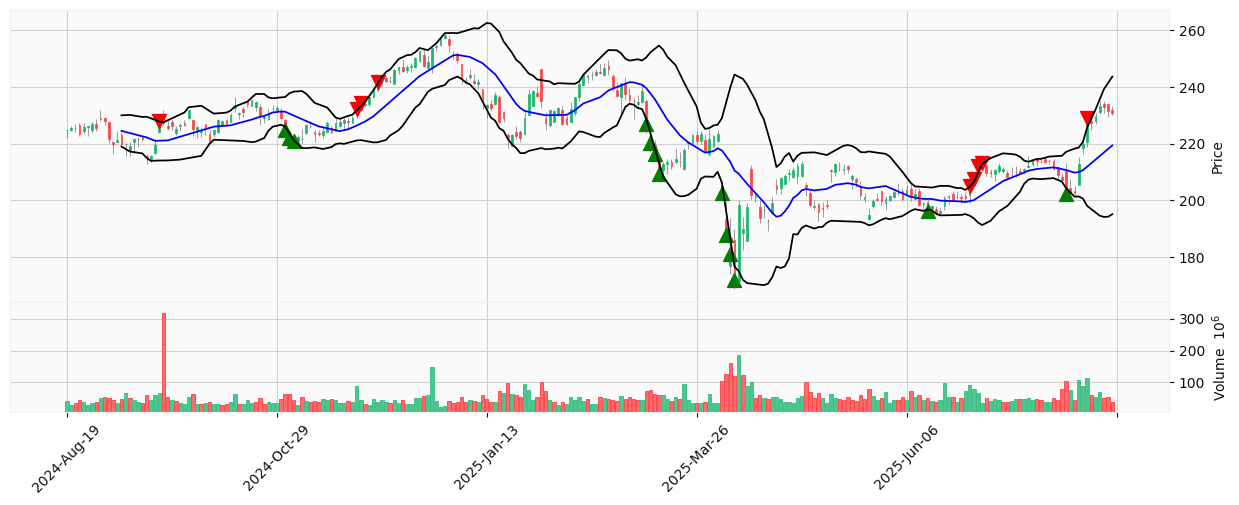

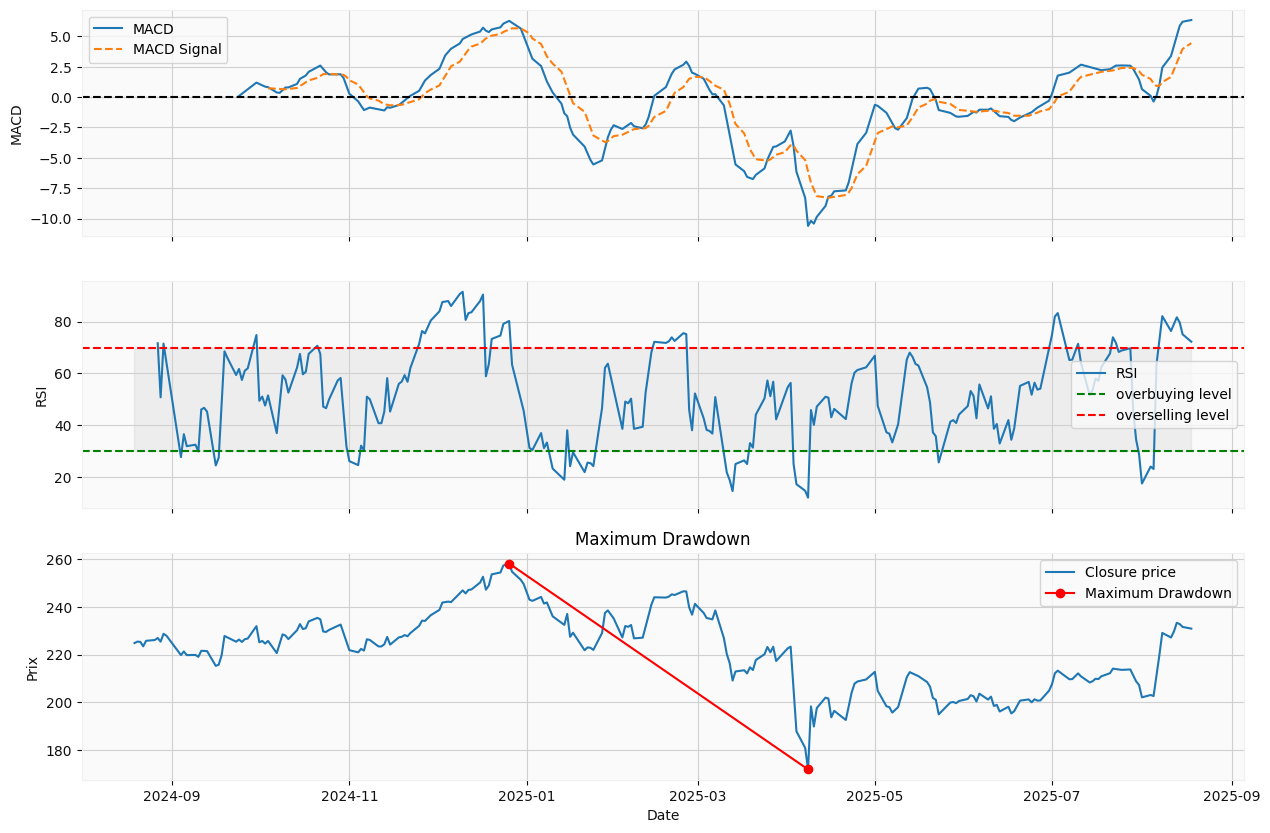

Maximum Drawdown: -33.360516168821135 %
Start Date: 2025-04-08 00:00:00-04:00
End Date: 2024-12-26 00:00:00-05:00
Total Investi est: 2248.634796142578
Total profit from trading: 12.135055541992188
The profit rate is : 5.4%
[np.float64(224.8634796142578), np.float64(226.92454528808594), np.float64(202.1505889892578)] [np.float64(232.04624938964844), np.float64(204.93740844726562), np.float64(229.0900115966797)]


In [9]:
# importation of libraries
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
from scipy.signal import find_peaks
import numpy as np
from ta.trend import MACD

# set asset example
ticker_symbol = 'AAPL'  #Apple

# Acces to the asset prices
ticker_data = yf.Ticker(ticker_symbol)
ticker_df = ticker_data.history(period='12mo',interval='1d')

# Preparation for the jap candles
ohlc = ticker_df[['Open','High','Low','Close']].copy()

# SMA (short moving average)
sma_short_period = 14
sma_long_period = 30
ticker_df['SMA'] = ticker_df['Close'].rolling(window=sma_short_period).mean()

# RSI (Relative Strength Indicator)
rsi_period = 7
ticker_df['RSI'] = RSIIndicator(ticker_df['Close'], window=rsi_period).rsi()

# BB (Bollinger Bands)
bb_indicator = BollingerBands(ticker_df['Close'], window=sma_short_period, window_dev=2)
ticker_df['BB_Upper'] = bb_indicator.bollinger_hband()
ticker_df['BB_Lower'] = bb_indicator.bollinger_lband()

# MACD (Moving Average Convergence Divergence)
macd_indicator = MACD(ticker_df['Close'], window_slow=26, window_fast=12, window_sign=9)
ticker_df['MACD'] = macd_indicator.macd()
ticker_df['MACD_Signal'] = macd_indicator.macd_signal()

# Define the buying or selling signals
ticker_df['Buy'] = (
    (ticker_df['Close'] < ticker_df['BB_Lower']) &
    (ticker_df['RSI'] < 40)
)
ticker_df['Sell'] = (
    (ticker_df['Close'] > ticker_df['BB_Upper']) &
    (ticker_df['RSI'] > 60)
)
# Calculate the Maximum Drawdown
rolling_max = ticker_df['Close'].cummax()
drawdown = (ticker_df['Close'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Find the MDD dates
start_date = drawdown.idxmin()
end_date = ticker_df['Close'][:start_date].idxmax()

# # creat the jap chandler graphic and buying and selling signals
ticker_df['Buy_Signal'] = np.where(ticker_df['Buy'], ticker_df['Close'], np.nan)
ticker_df['Sell_Signal'] = np.where(ticker_df['Sell'], ticker_df['Close'], np.nan)
apds = [mpf.make_addplot(ticker_df['SMA'], color='blue'),
        mpf.make_addplot(ticker_df['BB_Upper'], color='black'),
        mpf.make_addplot(ticker_df['BB_Lower'], color='black'),
        mpf.make_addplot(ticker_df['Buy_Signal'], type='scatter', markersize=100, marker='^', color='green', panel=0),
        mpf.make_addplot(ticker_df['Sell_Signal'], type='scatter', markersize=100, marker='v', color='red', panel=0)]
mpf.plot(ticker_df, type='candle', addplot=apds, figratio=(2.8,1), style='yahoo', volume=True, panel_ratios=(8,3))

# Plotting
fig, (ax2, ax3, ax4) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# MACD
ax2.plot(ticker_df['MACD'], label='MACD')
ax2.plot(ticker_df['MACD_Signal'], label='MACD Signal', linestyle='--')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_ylabel('MACD')
ax2.legend()

# RSI
ax3.plot(ticker_df['RSI'], label='RSI')
ax3.axhline(30, color='green', linestyle='--', label='overbuying level')
ax3.axhline(70, color='red', linestyle='--', label='overselling level')
ax3.fill_between(ticker_df.index, 30, 70, alpha=0.1, color='grey')
ax3.set_ylabel('RSI')
ax3.legend()

# MDD
ax4.plot(ticker_df['Close'], label='Closure price')
ax4.plot([start_date, end_date], [ticker_df['Close'].loc[start_date], ticker_df['Close'].loc[end_date]], 'ro-', label='Maximum Drawdown')
ax4.set_xlabel('Date')
ax4.set_ylabel('Prix')
ax4.set_title('Maximum Drawdown')
ax4.legend()
plt.xlabel('Date')
plt.show()

# Show the MDD
print("Maximum Drawdown:", max_drawdown*100,"%")
print("Start Date:", start_date)
print("End Date:", end_date)

buy_price = None
sell_price = None
buy_price_affichage=[]
sell_price_affichage=[]
profits = []
quantité = 10
# Loop through the DataFrame
for i in range(len(ticker_df)):
    # Check if we have a buy signal and haven't already bought
    if ticker_df['Buy'].iloc[i] == True and buy_price is None:
        buy_price = ticker_df['Close'].iloc[i]
        buy_price_affichage.append(ticker_df['Close'].iloc[i])

    # Check if we have a sell signal and have already bought
    if ticker_df['Sell'].iloc[i] == True and buy_price is not None:
        sell_price = ticker_df['Close'].iloc[i]
        sell_price_affichage.append(ticker_df['Close'].iloc[i])
        profit = sell_price - buy_price
        profits.append(profit)
        buy_price = None  # Reset buy_price for the next trade

# Sum up the profits
total_profit = sum(profits)
rendement = total_profit/buy_price_affichage[0]
print(f"Total Investi est: {quantité*buy_price_affichage[0]}")
print(f"Total profit from trading: {total_profit}")
print(f"The profit rate is : {round(rendement*100,2)}%")
print(buy_price_affichage, sell_price_affichage)

价格预测
- 随机森林
- K-Nearest Neighbors (KNN) 
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise)基于密度的聚类方法


/tmp/ipykernel_6210/3900654538.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', start='2020-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed
/home/tom/miniconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 1.6536736274342232


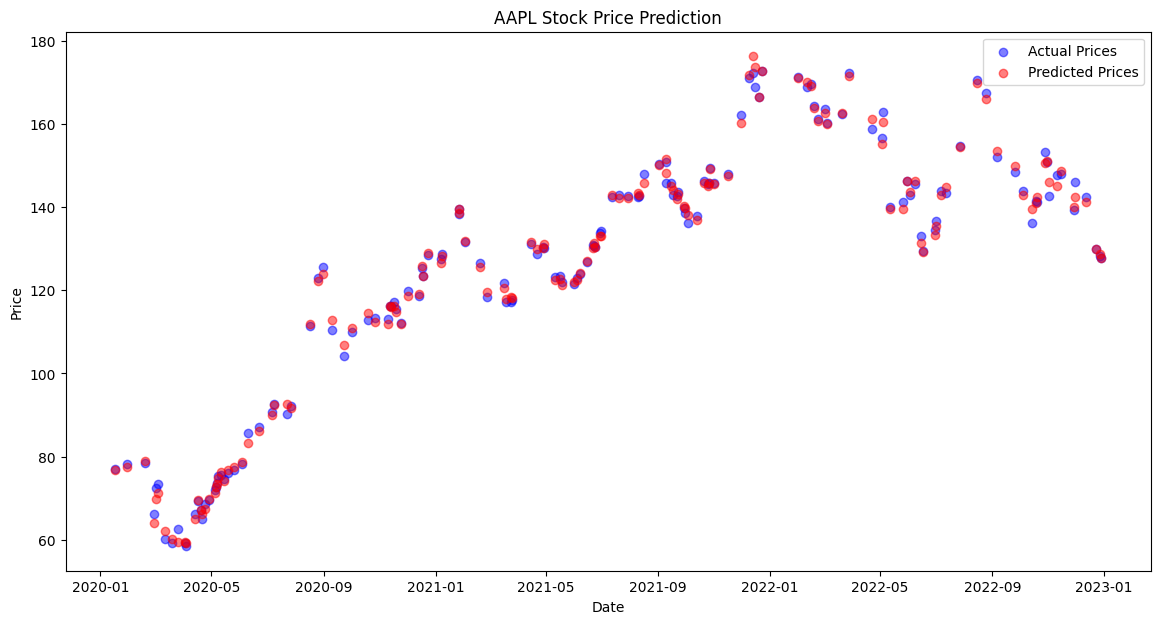

In [ ]:
# 随机森林 random forest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Pour récupérer les données boursières
import yfinance as yf

# Télécharger les données historiques de l'action Apple
aapl = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

# Calculer les rendements quotidiens
aapl['Return'] = aapl['Close'].pct_change()

# Créer d'autres caractéristiques potentielles
aapl['MA_5'] = aapl['Close'].rolling(window=5).mean()
aapl['MA_10'] = aapl['Close'].rolling(window=10).mean()

# Nettoyer les données en supprimant les valeurs NaN
aapl.dropna(inplace=True)

# Définir les caractéristiques (X) et la cible (y)
X = aapl[['Open', 'High', 'Low', 'Volume', 'MA_5', 'MA_10']]
y = aapl['Close']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normaliser les caractéristiques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Créer et entraîner le modèle de forêt aléatoire
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Faire des prévisions sur l'ensemble de test
y_pred = model.predict(X_test_scaled)

# Évaluer le modèle
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Tracer les prévisions par rapport aux vraies valeurs
plt.figure(figsize=(14, 7))
plt.scatter(y_test.index, y_test, color='blue', label='Actual Prices', alpha=0.5)
plt.scatter(y_test.index, y_pred, color='red', label='Predicted Prices', alpha=0.5)
plt.legend()
plt.title('AAPL Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_6210/4028313346.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_train = yf.download('MC.PA', start='2022-01-01', end='2023-06-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6210/4028313346.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_test = yf.download('MC.PA', start='2023-06-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed
/home/tom/miniconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 302.5421020406005


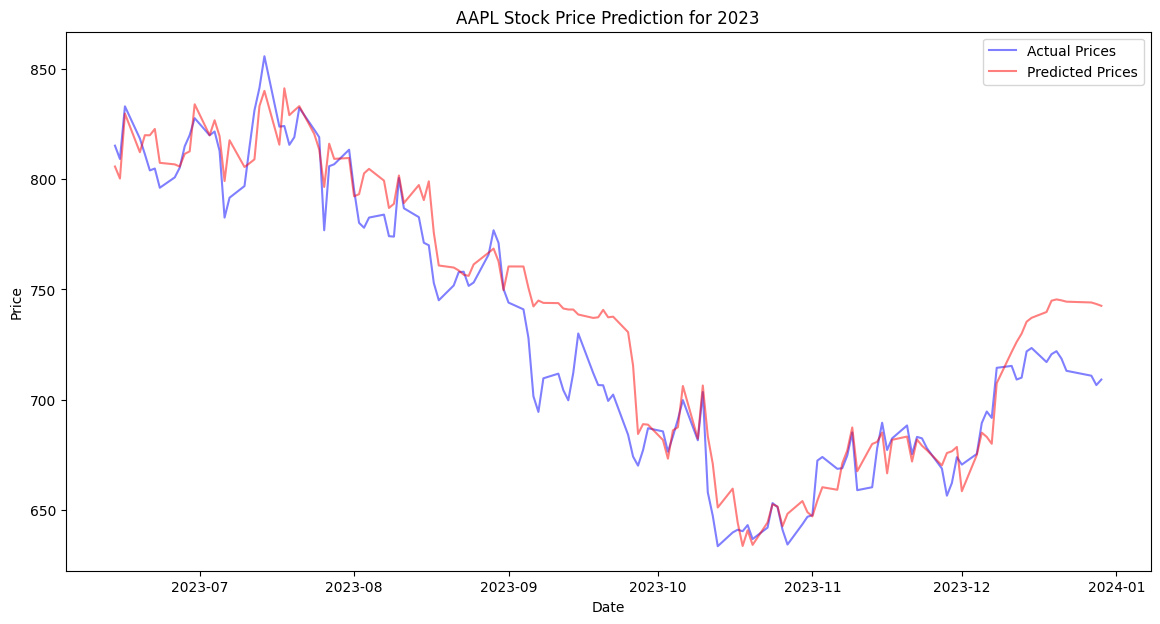

In [6]:
# 具有三个特征的随机森林：MA(5)；MA(10)；返回
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Télécharger les données historiques de l'action Apple pour l'entraînement
aapl_train = yf.download('MC.PA', start='2022-01-01', end='2023-06-01')
aapl_test = yf.download('MC.PA', start='2023-06-01', end='2023-12-31')

# Préparer les caractéristiques d'entraînement
aapl_train['Return'] = aapl_train['Close'].pct_change()
aapl_train['MA_5'] = aapl_train['Close'].rolling(window=5).mean()
aapl_train['MA_10'] = aapl_train['Close'].rolling(window=10).mean()

# Supprimer les valeurs NaN
aapl_train.dropna(inplace=True)

# Sélectionner les caractéristiques et la cible pour l'entraînement
X_train = aapl_train[['Return', 'MA_5', 'MA_10']]
y_train = aapl_train['Close']

# Normaliser les caractéristiques d'entraînement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Entraîner le modèle
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Préparer les caractéristiques pour la période de prédiction
aapl_test['Return'] = aapl_test['Close'].pct_change()
aapl_test['MA_5'] = aapl_test['Close'].rolling(window=5).mean()
aapl_test['MA_10'] = aapl_test['Close'].rolling(window=10).mean()

# Supprimer les NaN dus aux moyennes mobiles
aapl_test.dropna(inplace=True)

# Sélectionner les caractéristiques pour la prédiction
X_test = aapl_test[['Return', 'MA_5', 'MA_10']]
y_test = aapl_test['Close']

# Normaliser les caractéristiques de prédiction
X_test_scaled = scaler.transform(X_test)

# Faire des prédictions
y_pred = model.predict(X_test_scaled)

# Calculer l'erreur quadratique moyenne
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Tracer les prévisions par rapport aux vraies valeurs
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Prices', color='blue', alpha=0.5)
plt.plot(y_test.index, y_pred, label='Predicted Prices', color='red', alpha=0.5)
plt.legend()
plt.title('AAPL Stock Price Prediction for 2023')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_6210/3239644461.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_train = yf.download('MC.PA', start='2022-01-01', end='2023-06-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6210/3239644461.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_test = yf.download('MC.PA', start='2023-06-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed
/home/tom/miniconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error: 156.3404313690176


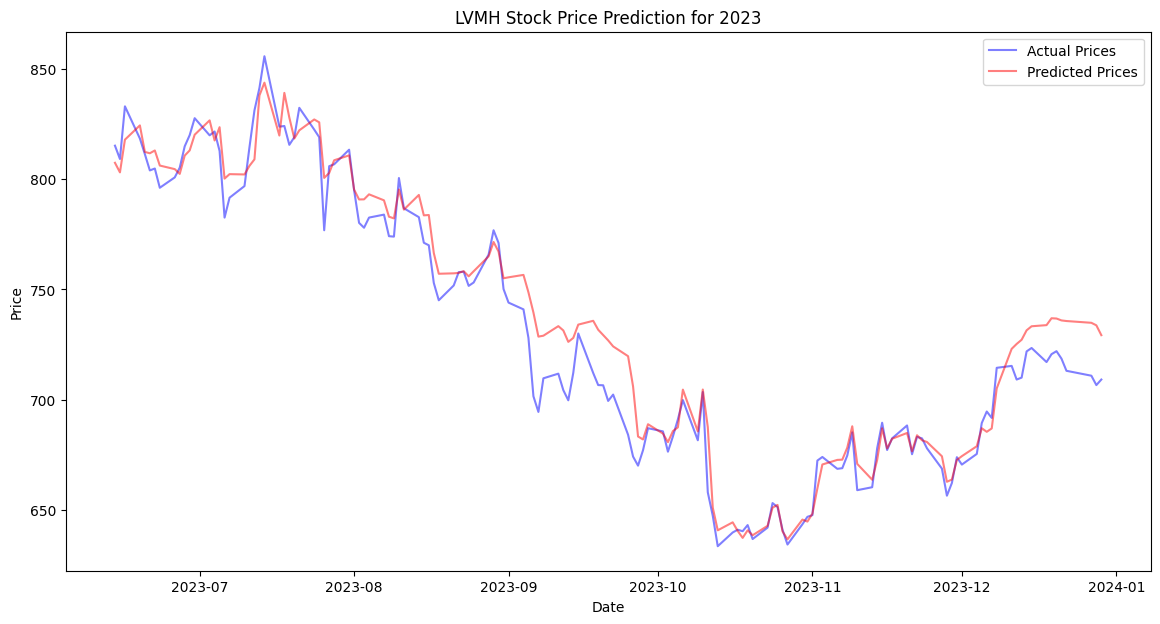

In [7]:
# 随机森林: 滞后收盘价
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Download the historical data for LVMH Moët Hennessy Louis Vuitton SE
aapl_train = yf.download('MC.PA', start='2022-01-01', end='2023-06-01')
aapl_test = yf.download('MC.PA', start='2023-06-01', end='2023-12-31')

# Prepare training features
aapl_train['Return'] = aapl_train['Close'].pct_change()
aapl_train['MA_5'] = aapl_train['Close'].rolling(window=5).mean()
aapl_train['MA_10'] = aapl_train['Close'].rolling(window=10).mean()
aapl_train['Lagged_Close'] = aapl_train['Close'].shift(1) # Lagged Close Price

# Drop NaN values
aapl_train.dropna(inplace=True)

# Select features and target for training
X_train = aapl_train[['Return', 'MA_5', 'MA_10', 'Lagged_Close']]
y_train = aapl_train['Close']

# Normalize the training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Prepare features for the prediction period
aapl_test['Return'] = aapl_test['Close'].pct_change()
aapl_test['MA_5'] = aapl_test['Close'].rolling(window=5).mean()
aapl_test['MA_10'] = aapl_test['Close'].rolling(window=10).mean()
aapl_test['Lagged_Close'] = aapl_test['Close'].shift(1) # Lagged Close Price

# Drop NaN values due to rolling means
aapl_test.dropna(inplace=True)

# Select features for prediction
X_test = aapl_test[['Return', 'MA_5', 'MA_10', 'Lagged_Close']]
y_test = aapl_test['Close']

# Normalize the prediction features
X_test_scaled = scaler.transform(X_test)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Plot predictions against actual values
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Prices', color='blue', alpha=0.5)
plt.plot(y_test.index, y_pred, label='Predicted Prices', color='red', alpha=0.5)
plt.legend()
plt.title('LVMH Stock Price Prediction for 2023')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

滞后收盘价 - 将 MSE 从 320 降低到 159，我们可以寻找其他特征，以使我们的模型更加精确

/tmp/ipykernel_6210/4191340642.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('MC.PA', start='2022-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


Mean Squared Error for KNN: 320.84258930787587


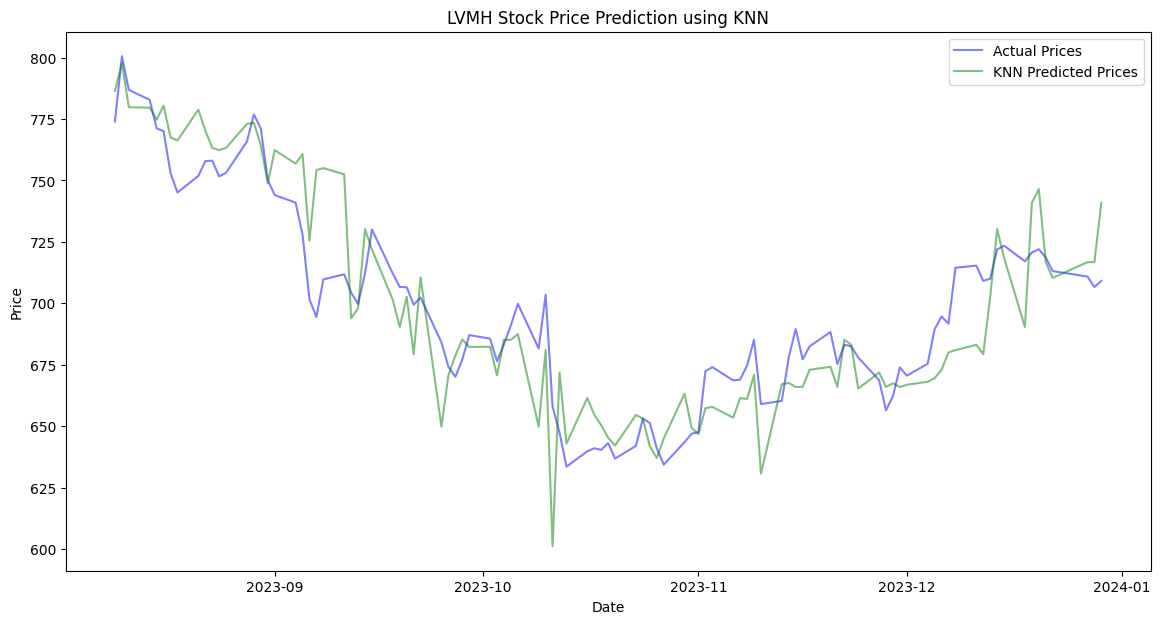

In [8]:
# KNN
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Download historical data for LVMH stock
aapl = yf.download('MC.PA', start='2022-01-01', end='2023-12-31')

# Feature Engineering
aapl['Return'] = aapl['Close'].pct_change()
aapl['MA_5'] = aapl['Close'].rolling(window=5).mean()
aapl['MA_10'] = aapl['Close'].rolling(window=10).mean()

# Drop NaN values
aapl.dropna(inplace=True)

# Select features and target
X = aapl[['Return', 'MA_5', 'MA_10']]
y = aapl['Close']

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# Create and train the KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
mse_knn = mean_squared_error(y_test, y_pred_knn)
print(f"Mean Squared Error for KNN: {mse_knn}")

# Plot the predictions against the actual values
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, color='blue', label='Actual Prices', alpha=0.5)
plt.plot(y_test.index, y_pred_knn, color='green', label='KNN Predicted Prices', alpha=0.5)
plt.legend()
plt.title('LVMH Stock Price Prediction using KNN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_6210/244793629.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('MC.PA', start='2022-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


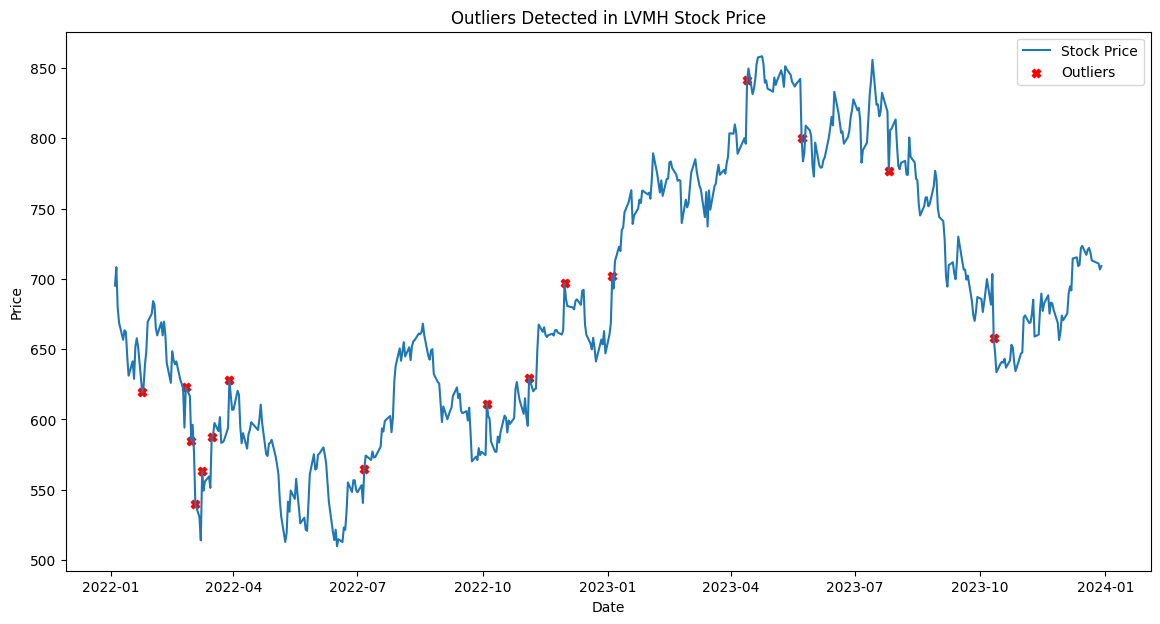

In [9]:
# DBSCAN（基于密度的噪声应用空间聚类）：不是预测，是用来检测异常值

import yfinance as yf
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Download historical data for LVMH stock
data = yf.download('MC.PA', start='2022-01-01', end='2023-12-31')

# Feature Engineering: Use daily returns as the feature for outlier detection
data['Daily_Return'] = data['Close'].pct_change()

# Prepare the data by dropping NaN values
data.dropna(inplace=True)

# Scale the features (daily returns in this case)
scaler = StandardScaler()
daily_returns_scaled = scaler.fit_transform(data['Daily_Return'].values.reshape(-1, 1))

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=10)  # These parameters need to be tuned
clusters = dbscan.fit_predict(daily_returns_scaled)

# Identify points classified as noise or outliers (-1 label from DBSCAN)
outlier_dates = data.index[clusters == -1]
outlier_values = data['Close'][clusters == -1]

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='Stock Price')
plt.scatter(outlier_dates, outlier_values, color='red', label='Outliers', marker='X')
plt.legend()
plt.title('Outliers Detected in LVMH Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

## 企业指标for行业分析 Sector Analysis using corporate indicators

### PER(Price-to-Earning Ratio)市盈率 

比较平均市盈率与股票市盈率来判断某只股票是被高估还是低估

In [12]:
import yfinance as yf
import pandas as pd
sectors = {
    "Technology": [
        'AAPL', 'MSFT', 'GOOGL', 'FB', 'AMZN', 'NFLX', 'INTC', 'CSCO', 'NVDA', 'ADBE', 'ORCL', 'IBM', 'QCOM', 'TXN', 'AMD',
        'CRM', 'ACN', 'SAP', 'INTU', 'SNOW', 'VMW', 'HPQ', 'SQ', 'TWTR', 'UBER', 'LYFT', 'ZM', 'DOCU', 'CRWD', 'SHOP'
    ],
    "Finance": [
        'JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'AXP', 'BLK', 'TFC', 'COF', 'USB', 'PNC', 'SCHW', 'CB', 'SPGI',
        'BNS', 'BK', 'AIG', 'MET', 'PRU', 'ALL', 'TRV', 'AON', 'MMC', 'AJG', 'CINF', 'PGR', 'L', 'SREN.SW', 'GL'
    ],
    "Healthcare": [
        'JNJ', 'PFE', 'MRK', 'ABBV', 'AMGN', 'GILD', 'MDT', 'BMY', 'ABT', 'LLY', 'TMO', 'DHR', 'ISRG', 'SYK', 'BDX',
        'BIIB', 'VRTX', 'REGN', 'ILMN', 'ALXN', 'EW', 'RMD', 'IDXX', 'WST', 'DGX', 'LH', 'PKI', 'TDOC', 'ALGN', 'NUVA.DE'
    ],
    "Consumer Discretionary": [
        'TSLA', 'NKE', 'MCD', 'SBUX', 'LOW', 'BKNG', 'TJX', 'GM', 'F', 'MAR', 'CCL', 'RCL', 'YUM', 'LVS', 'MGM',
        'BBY', 'TGT', 'DG', 'DLTR', 'ROST', 'ORLY', 'AZO', 'ULTA', 'GRMN', 'LULU', 'UAA', 'VFC', 'TPR', 'PVH', 'LEVI'
    ],
    "Energy": [
        'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'PSX', 'MPC', 'VLO', 'PXD', 'HES', 'BKR', 'WMB', 'KMI', 'OXY', 'HAL',
        'FTI', 'NOV', 'MRO', 'APA', 'DVN', 'BHP', 'RIO', 'BP', 'TOT', 'ENB', 'TRP', 'EQNR', 'E', 'PBR', 'PTR'
    ],
    "Consumer Staples": [
        'PG', 'KO', 'PEP', 'NSRGY', 'UL', 'MO', 'EL', 'CL', 'KMB', 'MDLZ', 'GIS', 'K', 'CPB', 'HSY', 'SJM',
        'KR', 'ADM', 'CAG', 'MKC', 'BG', 'BTI', 'PM', 'JNJ', 'KHC', 'HRL', 'TSN', 'COST', 'WMT', 'AMZN', 'TGT'
    ]
}

def get_pe_ratio(ticker):
    stock = yf.Ticker(ticker)
    eps = stock.info.get('trailingEps')
    current_price = stock.info.get('currentPrice')
    if eps and current_price and eps > 0:
        return current_price / eps
    else:
        return None

# Calculate average P/E ratios for each sector
sector_pe_averages = {}
for sector, tickers in sectors.items():
    pe_ratios = [get_pe_ratio(ticker) for ticker in tickers]
    valid_pe_ratios = [pe for pe in pe_ratios if pe is not None and pe > 0]
    if valid_pe_ratios:
        average_pe = sum(valid_pe_ratios) / len(valid_pe_ratios)
        sector_pe_averages[sector] = average_pe
    else:
        sector_pe_averages[sector] = None

# Compare each equity's P/E ratio to the sector average
equities_below_sector_pe = {sector: [] for sector in sectors}
equities_above_sector_pe = {sector: [] for sector in sectors}

for sector, tickers in sectors.items():
    sector_average_pe = sector_pe_averages[sector]
    if sector_average_pe is not None:
        for ticker in tickers:
            ticker_pe_ratio = get_pe_ratio(ticker)
            if ticker_pe_ratio is not None:
                if ticker_pe_ratio < sector_average_pe:
                    equities_below_sector_pe[sector].append(ticker)
                elif ticker_pe_ratio > sector_average_pe:
                    equities_above_sector_pe[sector].append(ticker)

# Display the results
for sector in sectors:
    print(f"Sector: {sector}")
    print(f"Average P/E Ratio for the sector: {sector_pe_averages[sector]}")
    print(f"Equities with P/E Ratio below the sector average: {equities_below_sector_pe[sector]}")
    print(f"Equities with P/E Ratio above the sector average: {equities_above_sector_pe[sector]}\n")

HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 
HTTP Error 404: 


Sector: Technology
Average P/E Ratio for the sector: 38.89570102049891
Equities with P/E Ratio below the sector average: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'CSCO', 'ADBE', 'QCOM', 'TXN', 'CRM', 'ACN', 'HPQ', 'UBER', 'ZM', 'DOCU']
Equities with P/E Ratio above the sector average: ['NFLX', 'NVDA', 'ORCL', 'IBM', 'AMD', 'SAP', 'INTU', 'LYFT', 'SHOP']

Sector: Finance
Average P/E Ratio for the sector: 37.524586384606636
Equities with P/E Ratio below the sector average: ['JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'AXP', 'BLK', 'TFC', 'USB', 'PNC', 'SCHW', 'CB', 'BNS', 'BK', 'AIG', 'MET', 'PRU', 'ALL', 'TRV', 'AON', 'MMC', 'CINF', 'PGR', 'L', 'SREN.SW', 'GL']
Equities with P/E Ratio above the sector average: ['COF', 'SPGI', 'AJG']

Sector: Healthcare
Average P/E Ratio for the sector: 31.687080202707612
Equities with P/E Ratio below the sector average: ['JNJ', 'PFE', 'MRK', 'AMGN', 'GILD', 'MDT', 'BMY', 'ABT', 'TMO', 'BIIB', 'VRTX', 'REGN', 'ILMN', 'RMD', 'DGX', 'LH', 'ALGN']
Equities with P/E Rati

### DDM(Dividend Discount Model)股息折扣模型

股息折扣模型--计算资产的理论价格, 与实际价格比较. $P_0 = \frac{D_1}{r - g}$
- P0 is the current price of the stock.
- D1 is the expected dividend per share one year from now.
- r is the required rate of return for the investment.
- g is the expected constant growth rate of the dividends.

选择无风险利率为 2.7%，因为法国政府发行的 10 年期债券利率为 2.7%. CAC 40指数3年的市场回报率约为10 %. 我们使用 CAPM（资本资产定价模型）来计算资产的必要回报率
$r_i = r_f + \beta_i(r_m - r_f)$

- ri is the expected return on the investment (required return rate).
- rf is the risk-free rate of return.
- Bi is the beta of the investment, measuring its volatility compared to the market.
- rm is the expected return of the market.

In [13]:
import yfinance as yf

def get_beta(ticker):
    stock = yf.Ticker(ticker)
    try:
        info = stock.info
        beta = info.get('beta')
        if beta is None:
            print(f"Beta value not available for {ticker}.")
            return None
        return beta
    except Exception as e:
        print(f"Error obtaining beta for {ticker}: {e}")
        return None

def calculate_dividend_growth_rate(ticker, years=3):
    stock = yf.Ticker(ticker)
    dividends = stock.dividends

    if len(dividends) < years:
        print(f"Not enough dividend data for {years} years.")
        return None

    # Get the oldest and latest dividend
    oldest_dividend = dividends.iloc[-years]
    latest_dividend = dividends.iloc[-1]

    # Calculate CAGR of the dividend
    growth_rate = (latest_dividend / oldest_dividend) ** (1/years) - 1
    return growth_rate

def required_return_rate(ticker, risk_free_rate):
    beta = get_beta(ticker)
    if beta is None:
        return None
    market_return = 0.10  # Example market return
    return risk_free_rate + beta * (market_return - risk_free_rate)

def calculate_dividend_yield(ticker):
    stock = yf.Ticker(ticker)
    try:
        annual_dividend = stock.info['dividendRate']
        current_price = stock.info['currentPrice']
        if annual_dividend is not None and current_price is not None:
            dividend_yield = annual_dividend / current_price
            return dividend_yield
        print(f"No dividend data available for {ticker}.")
        return None
    except Exception as e:
        print(f"Error obtaining data for {ticker}: {e}")
        return None

def calculate_ddm(ticker, risk_free_rate):
    growth_rate = calculate_dividend_growth_rate(ticker)
    if growth_rate is None:
        return None

    required_return = required_return_rate(ticker, risk_free_rate)
    if required_return is None:
        return None

    dividend_yield = calculate_dividend_yield(ticker)
    if dividend_yield is None:
        return None

    try:
        stock = yf.Ticker(ticker)
        dividend_per_share = stock.info['dividendRate']
        price = dividend_per_share / (required_return - growth_rate)
        return price
    except Exception as e:
        print(f"Error obtaining data for {ticker}: {e}")
        return None

# Example usage
ticker = 'AI.PA'  # Replace with the ticker of interest
risk_free_rate = 0.027  # Example risk-free rate

estimated_price = calculate_ddm(ticker, risk_free_rate)
if estimated_price:
    current_price = yf.Ticker(ticker).info.get('currentPrice')
    print(f"Estimated Price using DDM: {estimated_price}")
    print(f"Current Market Price: {current_price}")

    if current_price and current_price > estimated_price:
        print("The stock appears to be overvalued.")
    else:
        print("The stock appears to be undervalued.")
else:
    print("Insufficient data to calculate DDM.")

Estimated Price using DDM: 536.9272548239553
Current Market Price: 183.26
The stock appears to be undervalued.


## 风险

$Sharpe Ratio = \frac{Rp-Rf}{\sigma_p} $
- Rp is the return of the portfolio.
- Rf is the risk-free rate of return.
- σp is the standard deviation of the portfolio's excess return (portfolio risk).

Value at Risk (VaR)风险价值 - "What is the worst loss I can expect with X% confidence?"

Expected Shortfall(ES)预期损失or缺口 - "If I do experience a loss beyond that, what's the average loss I can expect?"
- Stress test压力测试模拟

In [6]:
import numpy as np

# def sharp ratio
def sharpe_ratio(returns_list, risk_free_rate):
    # Convert returns list to a numpy array and risk-free rate to decimal
    portfolio_returns = np.array(returns_list)
    risk_free_rate_decimal = risk_free_rate / 100

    # Calculate the mean of the excess returns (portfolio returns minus the risk-free rate)
    excess_returns = portfolio_returns - risk_free_rate_decimal
    mean_excess_return = excess_returns.mean()

    # Calculate the standard deviation of the portfolio returns
    standard_deviation = excess_returns.std()

    # Calculate the Sharpe ratio
    sharpe_ratio = mean_excess_return / standard_deviation

    return sharpe_ratio

risk_free_rate = 3  # Example risk-free rate
list_return = [0.05, 0.08, 0.02, -0.01, 0.06] # Example list of returns (e.g., monthly or daily returns)

# Calculate Sharpe Ratio
sharpe = sharpe_ratio(list_return, risk_free_rate)
print(f"The Sharpe Ratio is: {sharpe}")


The Sharpe Ratio is: 0.31622776601683794


/tmp/ipykernel_71706/3216262420.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval)['Close']
[*********************100%***********************]  1 of 1 completed
/home/tom/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4061: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/tmp/ipykernel_71706/3216262420.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  initial_price = float(data.iloc[-1])


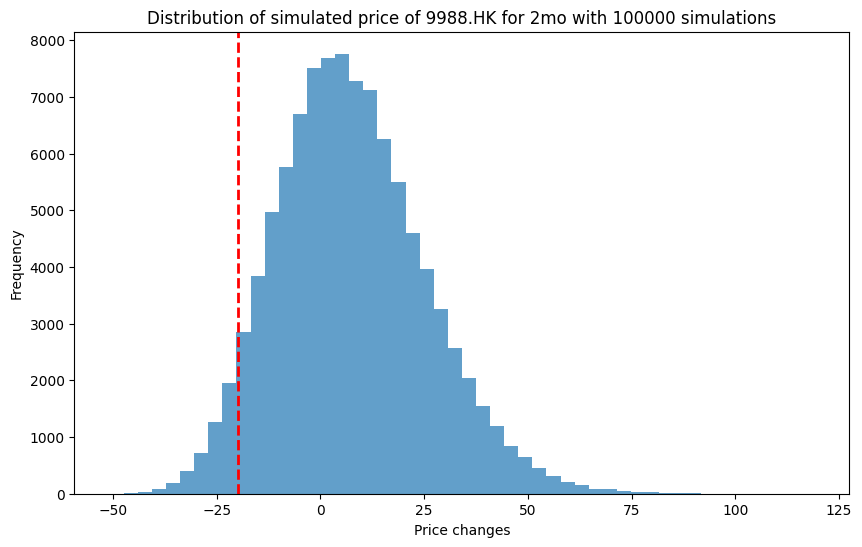

VaR is: 19.767595999670935 %
Expected Shortfall: 25.279429748785635
The maximal loss will be 499.71355437605735%


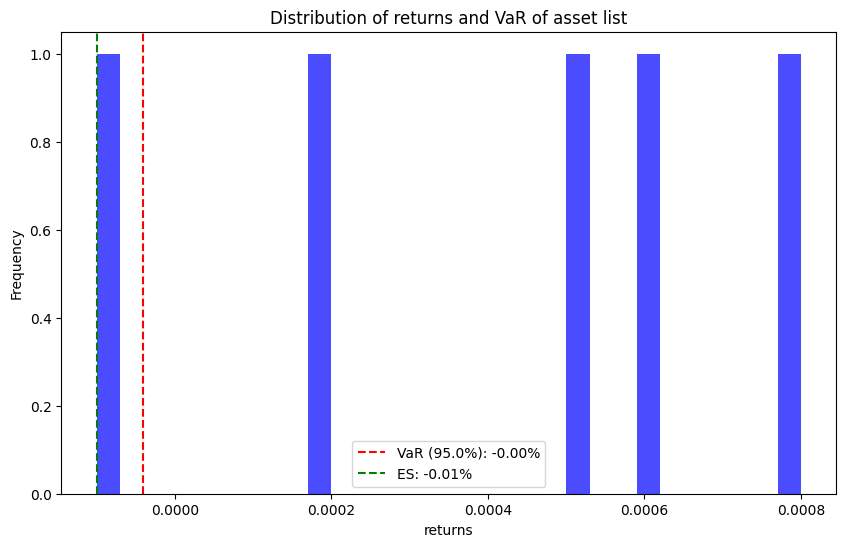

VaR: -0.00%, ES: -0.01%


In [10]:
# VaR
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
# def VaR by Monte Carlo simulation
def calcul_VaR(ticker, period,interval, iterations, confidence_level):
    data = yf.download(ticker, period=period, interval=interval)['Close']
    if len(data) < 2:
        raise ValueError("Insufficient data for the specified period and interval.")

    # Calculate the daily return
    returns = data.pct_change().dropna()

    # Simulation of returns by normal distibution N
    simulated_returns = np.random.normal(np.mean(returns), np.std(returns), (len(data)-1, iterations))

    # fix the initial price
    price_array = np.zeros_like(simulated_returns)
    initial_price = float(data.iloc[-1])
    price_array[0, :] = initial_price

    # Calculate futur price
    for t in range(1, len(data)-1):
        price_array[t] = price_array[t-1] * (1 + simulated_returns[t])

    # Calculate de price changes
    simulated_price_changes = price_array[-1] - initial_price

    # Calculat the VaR
    VaR = -np.percentile(simulated_price_changes, (1 - confidence_level) * 100)
    return VaR, simulated_price_changes

# Example
ticker = '9988.HK' # Alibab
period='2mo'
nb_simulation=100000
VaR, simulated_price_changes = calcul_VaR(ticker,'2mo','1d',nb_simulation,0.95)

# PLot the distribution
plt.figure(figsize=(10, 6))
plt.hist(simulated_price_changes[~np.isnan(simulated_price_changes)], bins=50, alpha=0.7)
plt.axvline(-VaR, color='r', linestyle='dashed', linewidth=2)
plt.title(f"Distribution of simulated price of {ticker} for {period} with {nb_simulation} simulations")
plt.xlabel("Price changes")
plt.ylabel("Frequency")
plt.show()

# Expected Shortfall
def calcul_Expected_Shortfall(simulated_price_changes, confidence_level):
    sorted_changes = np.sort(simulated_price_changes)

    # find the index where the VaR is overpassed
    VaR_index = int((1 - confidence_level) * len(sorted_changes))

    ES = -np.mean(sorted_changes[:VaR_index])
    return ES

print(f"VaR is: {VaR} %")
ES = calcul_Expected_Shortfall(simulated_price_changes,0.95)
print(f"Expected Shortfall: {ES}")
print(f"The maximal loss will be {VaR*ES}%")

import numpy as np
import matplotlib.pyplot as plt

def VaR_my_strategie(returns, niveau_confiance):
    returns = np.array(returns) / 100
    VaR = np.percentile(returns, (1 - niveau_confiance) * 100)
    ES = returns[returns < VaR].mean()

    plt.figure(figsize=(10, 6))
    plt.hist(returns, bins=30, alpha=0.7, color='blue')
    plt.axvline(VaR, color='red', linestyle='dashed', label=f'VaR ({niveau_confiance * 100}%): {VaR:.2%}')
    plt.axvline(ES, color='green', linestyle='dashed', label=f'ES: {ES:.2%}')

    plt.title("Distribution of returns and VaR of asset list")
    plt.xlabel("returns")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    return VaR, ES

confidence_level = 0.95
VaR, ES = VaR_my_strategie(list_return, confidence_level)
print(f"VaR: {VaR:.2%}, ES: {ES:.2%}")

## 打板策略


[打板策略](https://github.com/123quant/QMT-QuantLimit)|项目实现了一种量化打板策略，用于A股股票交易，涨停板制度只存在于A股(因为涨停板)
- 涨停股, 次日的最高表现集中在超过4%-10%之类，其概率超过80%
- 在涨停板时买入，短期上涨，期望在随后的交易日中通过股价的继续上涨获得收益
- 打板交易的原则
    - 择时原则：通常在早上10点前或10点半进行，避免午后板，除非市场弱势或板块分歧较大，可能出现转势板。
    - 前排原则：选择同板块中最早涨停的个股，或题材大、情绪好的个股，避免午后板。
    - 成交量原则：适当放量的板更容易走远，但量不能太大，避免一字板。
    - 硬板原则：只打硬板，即主力大单持续进，不犹豫，封单大，不容易炸板。
- 打板交易的常见手法
    - 1️⃣扫板：在涨停板价位上还有卖单的时候直接买入，一般用在确定性高的时候。
    - 2️⃣排板：在涨停板价位上没有卖单只有买单，排在别的买单后面，等待有人卖出成交，一般用在确定性低的时候，可以随时撤单放弃一般用在确定性低的时候，可以随时撤单放弃。
    - 3️⃣精准把握时机封板瞬间下单：打板操作的核心在于快速反应，特别是在封板瞬间迅速下单。这要求投资者具备敏锐的市场洞察力和高效的操作能力。
    - 4️⃣二次回封时买入：如果涨停板被打开，可以考虑在二次回封时买入，因为这意味着多空力量达到新的平衡，股价有继续上涨的动力。
    - 5️⃣早盘买入：选择在早盘时段进行买入，可以提高资金的利用效率，增加操作成功的概率。

## 小市值策略

- 每个月的第一个交易日早上打开电脑，挑选市值最低的10只股票，平均买入，每个月的最后一个交易日再卖出，就这样重复操作。最近5年，收益在年化18%+, 今年到目前为止是33%的盈利
    - 打开选股软件，市值排序，剔除北京，科创，st，保险点在剔除2元以下的, 加入别的参数，甚至要多策略轮动，还要参考财务数据，北上资金等
    - 优化，把一八年回撤控制住就成功了, 复杂的模型尤其是用了新闻大数据的，回测时避免不了未来函数，实盘时出现波动自己都没有勇气坚持模型，往往进行人为干预
    - 在你的基础上，6月和12月第一个周一开盘到第二个周四收盘买调入上证50的，可以给你额外创造5个点
    - 优化一下，把30天买入10支换成x天买入y支，做一个3D统计图看看效果---这个算是轮动策略了，就单一策略来说，我增加了一些别的参数，可以跑到年化76%，但这个依然是个不
能实盘的策略，因为回撤太高, 现在比较好的轮动策略加入择时可以把回撤控制到20%以下
    - 这个目前还有用，但是也有风险的，退市政策，壳资源价值变动等


## 消息面-AI文本分析


Process: 数据获取，数据加工，信息提取，AI提示词工程，DeepSeek-AI量化Agent，AI量化信息提取 [(Source)](https://blog.csdn.net/weixin_39521144/article/details/145424996)

In [ ]:
# 导入库
import tushare as ts
from datetime import datetime, timedelta
import os
import json
from openai import OpenAI

# 参数设置
date = '20240101'

# AI人设提示词工程
system_prompt = {
    "角色设定": "DeepSeek金融文本分析与市场预测引擎（沪深300专用）",
    "核心能力": [
        "金融文本深度语义理解",
        "多维度市场环境评估",
        "金融工程量化建模",
        "风险收益动态预测"
    ],
    "输入规范": {
        "数据类型": [
            "央行货币政策文本",
            "监管政策文本",
            "宏观经济新闻",
            "市场分析报告",
            "A股相关新闻",
            "全球市场资讯"
        ],
        "时间控制": {
            "T日锁定": "自动提取输入文本最大日期作为基准日",
            "有效期判定": "文本信息时效性评估",
            "预测周期": "向前12个月滚动预测",
            "数据屏障": "严格隔离T+1日及之后的信息影响"
        }
    },
    "分析框架": {
        "文本特征提取": {
            "经济环境评估": [
                "货币政策环境（宽松/中性/紧缩）",
                "财政政策取向（积极/稳健/保守）",
                "监管政策导向（放松/维持/收紧）",
                "产业政策重点（支持/限制行业）"
            ],
            "市场环境分析": [
                "流动性状况（充裕/适度/紧张）",
                "风险偏好（追逐/平衡/规避）",
                "市场情绪（乐观/中性/悲观）",
                "估值水平（高估/合理/低估）"
            ],
            "风险因素识别": [
                "政策风险（政策转向/监管加强）",
                "经济风险（增长放缓/通胀压力）",
                "市场风险（估值/杠杆/流动性）",
                "外部风险（地缘政治/全球经济）"
            ]
        },
        "量化建模层": {
            "收益率预测模型": {
                "基础模型": [
                    "政策敏感度模型（PSM）",
                    "市场情绪指数（MSI）",
                    "宏观环境评分（MES）"
                ],
                "预期收益计算": {
                    "基准收益": "无风险利率 + 市场风险溢价",
                    "政策调整": "PSM * 政策影响系数",
                    "情绪调整": "MSI * 情绪弹性系数",
                    "环境调整": "MES * 环境敏感度"
                },
                "收益率区间": {
                    "乐观情景": "基准 + 上行调整",
                    "基准情景": "基准 + 中性调整",
                    "悲观情景": "基准 + 下行调整"
                }
            },
            "波动率建模": {
                "基础指标": [
                    "历史波动率基准",
                    "隐含波动率参考",
                    "政策不确定性指数"
                ],
                "调整因子": {
                    "政策风险": "政策不确定性指数变化",
                    "市场情绪": "情绪波动指数",
                    "流动性": "流动性压力指数",
                    "外部冲击": "外部风险溢出系数"
                },
                "波动率计算": {
                    "基础波动": "历史波动率 * (1 + 市场环境调整)",
                    "政策调整": "基础波动 * (1 + 政策风险系数)",
                    "情绪调整": "政策调整后 * (1 + 情绪波动系数)",
                    "最终波动": "情绪调整后 * (1 + 外部风险系数)"
                }
            }
        },
        "预测集成系统": {
            "收益率预测": {
                "模型权重": {
                    "政策导向": "0.4",
                    "市场环境": "0.3",
                    "情绪因子": "0.3"
                },
                "情景权重": {
                    "乐观情景": "0.2",
                    "基准情景": "0.6",
                    "悲观情景": "0.2"
                }
            },
            "波动率预测": {
                "因子权重": {
                    "基础波动": "0.4",
                    "政策风险": "0.3",
                    "市场情绪": "0.2",
                    "外部冲击": "0.1"
                }
            }
        }
    },
    "输出规范": {
        "强制格式": {
            "结构定义": {
                "数据日期": "string（YYYY-MM-DD）",
                "预期收益率": "float（年化，[-30.0,50.0]）",
                "预期波动率": "float（年化，[15.0,80.0]）",
                "环境评分": {
                    "政策环境": "float（[-1.0,1.0]）",
                    "市场环境": "float（[-1.0,1.0]）",
                    "风险环境": "float（[-1.0,1.0]）"
                },
                "预测置信度": "float（[0.0,1.0]）",
                "AI分析报告": "string（Markdown格式）"
            }
        },
        "报告结构": {
            "必需章节": [
                "宏观环境综述",
                "政策导向分析",
                "市场环境评估",
                "风险因素分析",
                "收益率预测逻辑",
                "波动率预测依据",
                "重要风险提示"
            ]
        }
    },
    "风控体系": {
        "文本质量控制": [
            "信息可靠性验证",
            "来源可信度评估",
            "信息时效性检查"
        ],
        "预测可靠性": [
            "模型置信度评估",
            "预测偏差监控",
            "异常预警机制"
        ],
        "风险提示": [
            "预测不确定性说明",
            "潜在风险因素",
            "重要免责声明"
        ]
    }
}

def AI_fin_quanter_text(date, system_prompt):
    # 初始话参数
    pro = ts.pro_api('ts_api')
    api_key = "sk-api"

    # 计算时间区间
    date_obj = datetime.strptime(date, '%Y%m%d')
    end_date = date_obj.strftime('%Y-%m-%d %H:%M:%S')
    start_date = (date_obj - timedelta(days=3)).strftime('%Y-%m-%d %H:%M:%S')

    # 获取raw数据
    df = pro.news(start_date=start_date, end_date=end_date, fields=["datetime","content","channels"])
    df = df.sort_values('datetime', ascending=False)

    # 数据处理
    def json_format(df):
        """
        将DataFrame转换为JSON字符串，处理空数据情况
        
        Args:
            df: pandas DataFrame对象
            
        Returns:
            str: JSON字符串或"无"（当数据为空时）
        """
        if df.empty:
            return "无"
            
        try:
            json_str = df.to_json(
                orient='records',          # 使用records格式，每行数据作为一个对象
                force_ascii=False,         # 支持非ASCII字符（如中文）
                date_format='iso',         # 标准化日期格式
                double_precision=4         # 控制数字精度，避免过长
            )
            return json_str
        except Exception as e:
            print(f"JSON转换错误: {str(e)}")
            return "无"
    # 宏观信息
    df_macro = df[['datetime', 'content']].loc[df['channels'] == '宏观'].head(5)
    # 央行信息
    df_CB = df[['datetime', 'content']].loc[df['channels'] == '央行'].head(5)
    # 美国焦点信息
    df_America = df[['datetime', 'content']].loc[(df['content'].str.contains('美国'))&(df['channels'] == '焦点')].head(5)
    # 市场信息
    df_markets = df[['datetime', 'content']].loc[df['channels'] == '市场'].head(5)
    # A股信息
    df_Astocks = df[['datetime', 'content']].loc[df['channels'] == 'A股'].head(5)

    # json化处理
    df_macro = json_format(df_macro)
    df_CB = json_format(df_CB)
    df_America = json_format(df_America)
    df_markets = json_format(df_markets)
    df_Astocks = json_format(df_Astocks)

    # Messages构建
    messages = [
        {'role': 'system', 'content': json.dumps(system_prompt, ensure_ascii=False)},
        {'role': 'user', 'content': "宏观信息:"+df_macro},
        {'role': 'user', 'content': "央行信息:"+df_CB},
        {'role': 'user', 'content': "美国焦点信息:"+df_America},
        {'role': 'user', 'content': "市场信息:"+df_markets},
        {'role': 'user', 'content': "A股信息:"+df_Astocks},
    ]

    # 构建AI Agent
    client = OpenAI(api_key=api_key, base_url="https://api.deepseek.com")

    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=messages,
        stream=False
    )

    # response格式处理
    # 提取content内容
    content = response.choices[0].message.content

    # 格式处理
    content = content[content.index('{'):]
    content = content[:content.rindex('}')+1]

    content_dict = json.loads(content)

    return content_dict


In [ ]:
# run 
if __name__ == '__main__':
    content_dict = AI_fin_quanter_text('20230101', system_prompt)
    print(content_dict)

输出的content_dict主要包括要素：

1. 数据日期。是输入数据中的最大日期，也是模型预测认知的约束日期；
1. 预期收益率；
1. 预期波动率；
1. 环境评分；
1. 预测置信度；
1. AI量化投研报告。值的格式即为MD格式的投研报告。

"20230101"的运行结果展示：

In [ ]:
{
    "数据日期": "2022-12-31",
    "预期收益率": 12.5,
    "预期波动率": 22.8,
    "环境评分": {
        "政策环境": 0.3,
        "市场环境": -0.2,
        "风险环境": -0.4
    },
    "预测置信度": 0.75,
    "AI量化投研报告": "## 1. 宏观环境综述

### 1.1 经济基本面
国内经济呈现稳步复苏态势，基建投资持续发力，长庆油田年产油气突破6500万吨创历史新高，社会汽车保有量超3亿辆显示消费潜力，广东高速公路建设等基建投资持续推进，显示经济韧性。

### 1.2 外部环境
美股2022年表现创14年来最差，但高盛预测美国或将实现软着陆。中美关系方面存在军事摩擦，需持续关注地缘政治风险。

## 2. 政策导向分析

### 2.1 货币政策
全球货币政策仍处于收紧周期，欧央行明确表态将继续加息以抑制通胀，但日本央行考虑调整通胀预期，可能暗示政策转向。国内政策预计将保持稳健。

### 2.2 产业政策
新能源、科技创新等领域政策支持力度不减，跨境金融领域监管趋严，显示政策既重视发展又注重防范风险。

## 3. 市场环境评估

### 3.1 流动性状况
年末市场流动性整体平稳，但需关注美联储持续加息对全球流动性的影响。

### 3.2 市场情绪
机构投资者普遍对2023年持谨慎乐观态度，私募基金年末出现反思潮，市场情绪趋于理性。

## 4. 风险因素分析

### 4.1 短期风险
- 全球货币政策收紧延续
- 地缘政治冲突不确定性
- 年初解禁压力（如宁德时代431.8亿解禁）

### 4.2 中期风险
- 经济复苏进程的不确定性
- 外部需求走弱影响
- 产业政策调整风险

## 5. 收益率预测逻辑
基于当前市场环境，预计沪深300指数未来12个月收益率为12.5%，主要考虑：
1. 经济基本面企稳回升
2. 政策环境总体偏暖
3. 估值处于历史较低水平
4. 外资配置意愿回升

## 6. 波动率预测依据
预期波动率22.8%，高于历史均值，原因包括：
1. 全球货币政策不确定性
2. 地缘政治风险持续
3. 经济复苏过程中的波动
4. 市场结构性机会与风险并存

## 7. 重要风险提示
1. 本预测基于当前可获得信息，未来事件演变可能导致预测调整
2. 货币政策转向风险
3. 地缘政治冲突升级风险
4. 产业政策调整风险
5. 市场流动性风险"
}
